# Filtering and Extraction


In [ ]:
from pathlib import Path
import pandas as pd
import re

folder = Path("/cluster/project/reddy/katja/NGS_pipeline/data/P3408_LUCA-TCRA3/extracted")
summary_files = sorted(folder.glob("*.filtered.summary.tsv"))

print("Found", len(summary_files), "summary files")
summary_files[:3]


In [ ]:
def parse_summary_tsv(path: Path):
    text = path.read_text()
    sample = path.name.replace(".filtered.summary.tsv", "")  # sample ID from filename

    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]

    # find header lines
    idx_metric = next(i for i, ln in enumerate(lines) if ln.lower().startswith("metric"))
    idx_pos = next(i for i, ln in enumerate(lines) if ln.lower().startswith("fail_position_1based"))

    # ---- metric/value table
    metrics = []
    for ln in lines[idx_metric+1:idx_pos]:
        if ln.startswith("#"):
            continue
        parts = re.split(r"\s+", ln)
        if len(parts) == 2:
            metrics.append((sample, parts[0], int(parts[1])))

    metrics_df = pd.DataFrame(metrics, columns=["sample", "metric", "value"])

    # ---- position/count table
    pos = []
    for ln in lines[idx_pos+1:]:
        if ln.startswith("#"):
            continue
        parts = re.split(r"\s+", ln)
        if len(parts) == 2:
            pos.append((sample, int(parts[0]), int(parts[1])))

    pos_df = pd.DataFrame(pos, columns=["sample", "fail_position_1based", "count"])

    return metrics_df, pos_df



In [3]:
all_metrics = []
all_pos = []

for f in summary_files:
    mdf, pdf = parse_summary_tsv(f)
    all_metrics.append(mdf)
    all_pos.append(pdf)

metrics_long = pd.concat(all_metrics, ignore_index=True)
pos_long = pd.concat(all_pos, ignore_index=True)

metrics_wide = (
    metrics_long
    .pivot_table(index="sample", columns="metric", values="value", aggfunc="sum")
    .fillna(0)
    .astype(int)
)

# pass rate
metrics_wide["pass_rate"] = metrics_wide["pass"] / metrics_wide["total_reads"]

metrics_wide.head()


metric,fail_anchor_not_found,fail_contains_N,fail_degenerate_mismatch,fail_region_too_short,fail_stop_codon,pass,total_reads,pass_rate
sample,,,,,,,,
GFB-61811_clibMAGE-A32xnegative,364339,1943499,199981,1168,6967,6447235,8963189,0.719301
GFB-61812_clibTitin2xnegative,272327,1626413,184824,605,4473,5906351,7994993,0.738756
GFB-61813_clibKH1582xnegative,328366,1655953,176795,690,6394,6029680,8197878,0.735517
GFB-61814_clibKH1592xnegative,329623,2116408,203562,1591,5096,6847521,9503801,0.720503
GFB-61815_clibKH1602xnegative,292993,1403358,182316,860,4855,5545371,7429753,0.746374


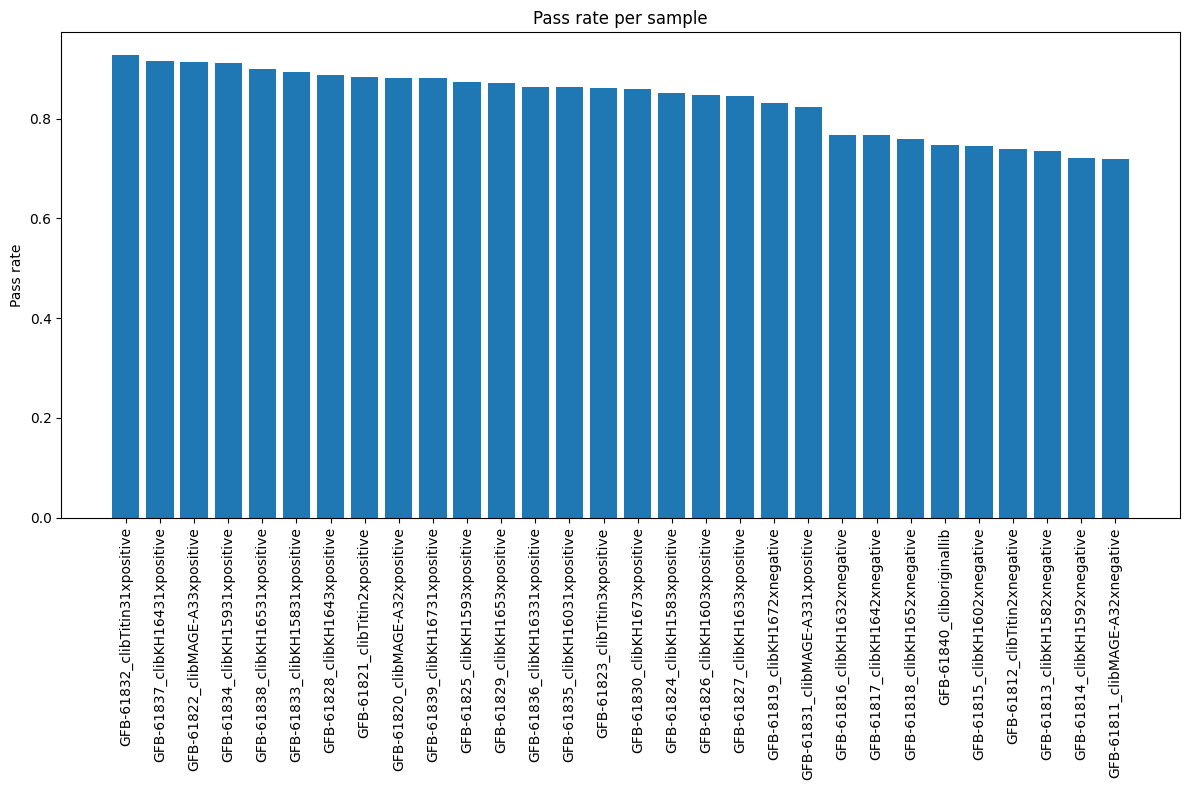

In [6]:
import matplotlib.pyplot as plt

df = metrics_wide.sort_values("pass_rate", ascending=False)

plt.figure(figsize=(12,8))
plt.bar(df.index, df["pass_rate"])
plt.xticks(rotation=90)
plt.ylabel("Pass rate")
plt.title("Pass rate per sample")
plt.tight_layout()
plt.show()



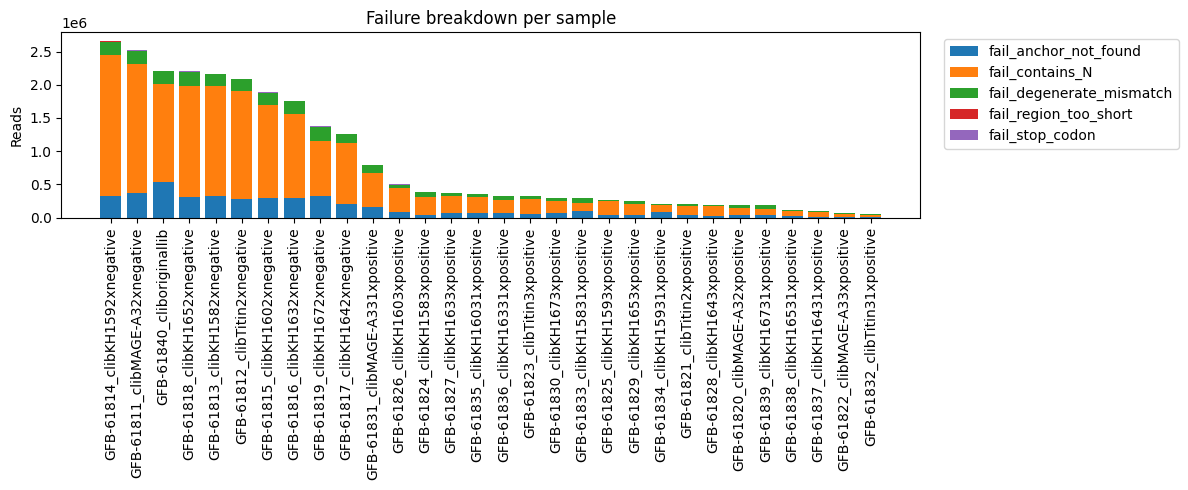

In [7]:
fail_cols = [c for c in metrics_wide.columns if c.startswith("fail_")]
df = metrics_wide[fail_cols].copy()
df["total_fail"] = df.sum(axis=1)
df = df.sort_values("total_fail", ascending=False).drop(columns="total_fail")

plt.figure(figsize=(12,5))
bottom = None
for col in df.columns:
    if bottom is None:
        plt.bar(df.index, df[col], label=col)
        bottom = df[col].values
    else:
        plt.bar(df.index, df[col], bottom=bottom, label=col)
        bottom = bottom + df[col].values

plt.xticks(rotation=90)
plt.ylabel("Reads")
plt.title("Failure breakdown per sample")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


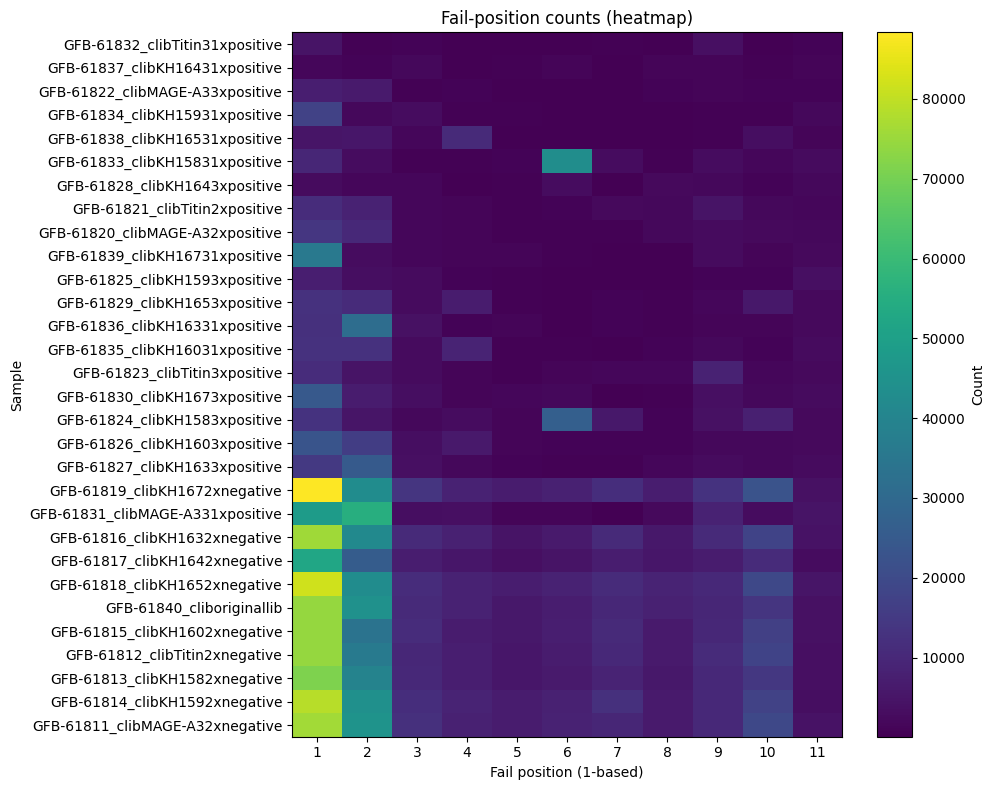

In [8]:
pos_wide = (
    pos_long
    .pivot_table(index="sample", columns="fail_position_1based", values="count", aggfunc="sum")
    .fillna(0)
)

# order samples by pass rate (nice for interpretation)
order = metrics_wide.sort_values("pass_rate", ascending=False).index
pos_wide = pos_wide.reindex(order)

plt.figure(figsize=(10,8))
plt.imshow(pos_wide.values, aspect="auto")
plt.yticks(range(len(pos_wide.index)), pos_wide.index)
plt.xticks(range(len(pos_wide.columns)), pos_wide.columns)
plt.xlabel("Fail position (1-based)")
plt.ylabel("Sample")
plt.title("Fail-position counts (heatmap)")
plt.colorbar(label="Count")
plt.tight_layout()
plt.show()


In [9]:
report = metrics_wide.copy()
report.to_csv(folder / "all_samples.filtered.summary.report.csv")
report.sort_values("pass_rate", ascending=False).head(10)


metric,fail_anchor_not_found,fail_contains_N,fail_degenerate_mismatch,fail_region_too_short,fail_stop_codon,pass,total_reads,pass_rate
sample,,,,,,,,
GFB-61832_clibTitin31xpositive,12186,29102,13245,0,305,697233,752071,0.927084
GFB-61837_clibKH16431xpositive,13850,70028,10434,0,140,1037427,1131879,0.916553
GFB-61822_clibMAGE-A33xpositive,9450,40457,19490,0,580,742524,812501,0.913875
GFB-61834_clibKH15931xpositive,87597,96068,27257,7,152,2204338,2415419,0.912611
GFB-61838_clibKH16531xpositive,28154,63366,28800,0,192,1081926,1202438,0.899777
GFB-61833_clibKH15831xpositive,91213,130956,67929,9,378,2461991,2752476,0.894464
GFB-61828_clibKH1643xpositive,29570,148977,16932,1,224,1549636,1745340,0.887871
GFB-61821_clibTitin2xpositive,41833,124740,34486,46,1735,1550142,1752982,0.884289
GFB-61820_clibMAGE-A32xpositive,35933,113367,36485,2,1118,1396152,1583057,0.881934
